--- 筛选结果 ---
   订单号  商品   单价   销量  备注    总金额
6  107  苹果  5.2  100  新鲜  520.0

--- 分组排序结果 ---
   商品     总金额
1  苹果  1770.0
3  香蕉  1020.0
0  橘子   824.0
2  葡萄   400.0


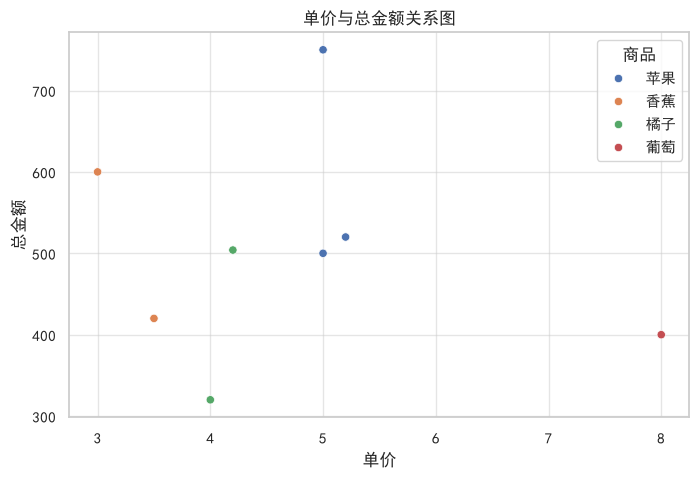

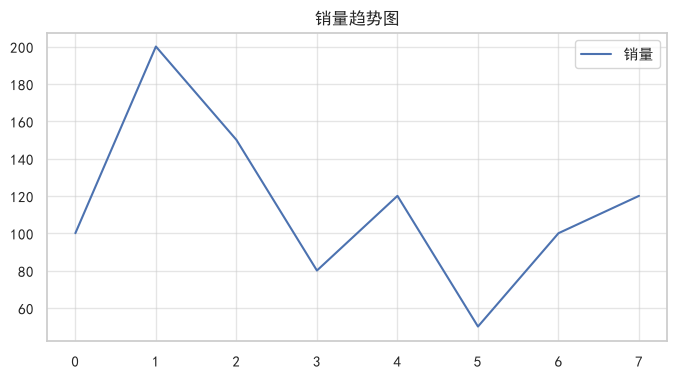

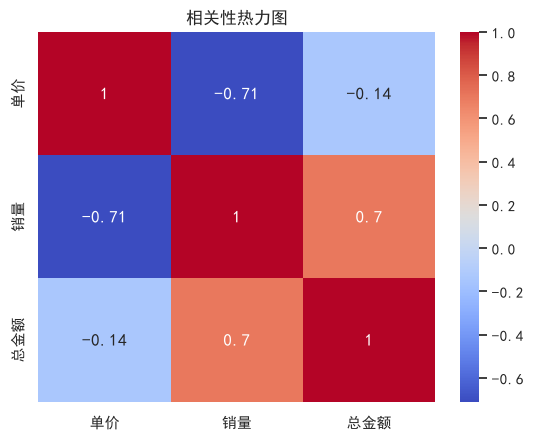

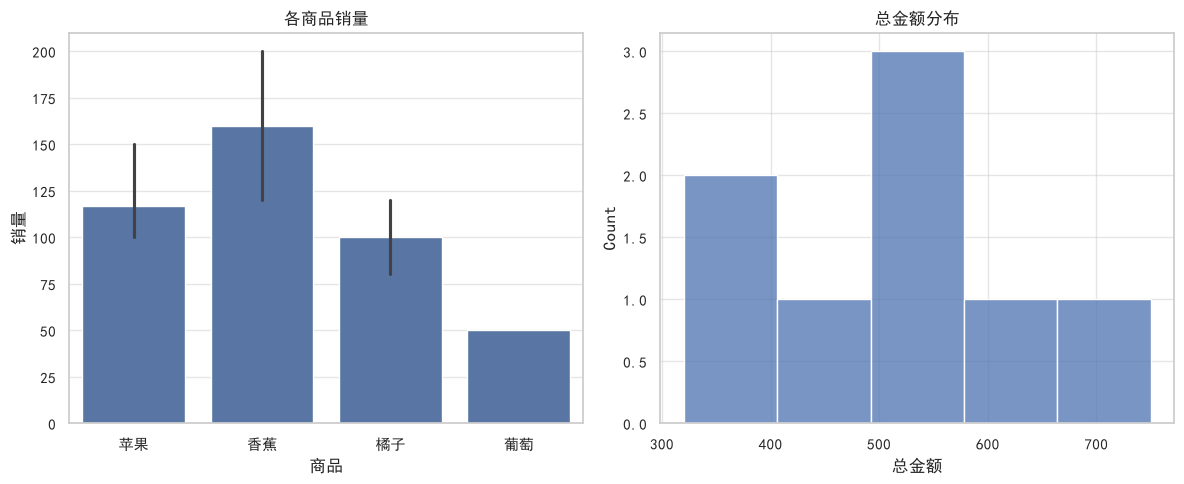


全部运行完毕，快去当前文件夹看看保存的图片吧！


In [1]:
# 第一步：导入需要的工具包
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 第二步：设置画图环境
sns.set_theme(style="whitegrid")               # 设置画图背景为白底网格
plt.rcParams['font.sans-serif'] = ['SimHei']   # 解决中文标题显示为方块的问题
plt.rcParams['axes.unicode_minus'] = False     # 解决坐标轴负号显示为方块的问题

# 第三步：准备数据（模拟一个电商销售表）
数据 = pd.DataFrame({
    '订单号': [101, 102, 103, 104, 105, 106, 107, 108],
    '商品': ['苹果', '香蕉', '苹果', '橘子', '香蕉', '葡萄', '苹果', '橘子'],
    '单价': [5.0, 3.0, 5.0, 4.0, 3.5, 8.0, 5.2, 4.2],
    '销量': [100, 200, 150, 80, 120, 50, 100, 120],
    '备注': ['新鲜', '打折', None, '新鲜', '打折', '进口', '新鲜', None]
})

# 第四步：数据清洗与处理
数据['备注'] = 数据['备注'].fillna('未知')       # 把备注里的空值（None）填成“未知”
数据['总金额'] = 数据['单价'] * 数据['销量']     # 新增一列“总金额”，等于单价乘销量

# 筛选出“总金额”大于 500，并且“备注”是“新鲜”的行（注意括号和 &）
条件筛选 = 数据[(数据['总金额'] > 500) & (数据['备注'] == '新鲜')]
print("--- 筛选结果 ---")
print(条件筛选)

# 按“商品”分组，计算每种商品的“总金额”总和，并降序排序
分组结果 = 数据.groupby('商品')['总金额'].sum().reset_index()  # 分组求和并重置索引
分组结果.sort_values(by='总金额', ascending=False, inplace=True) # 按总金额降序排序
print("\n--- 分组排序结果 ---")
print(分组结果)

# 第五步：Seaborn 画散点图
plt.figure(figsize=(8, 5))                       # 设置画布大小
sns.scatterplot(data=数据, x='单价', y='总金额', hue='商品') # 以单价为x轴，总金额为y轴，商品为颜色画散点图
plt.title("单价与总金额关系图")                    # 加标题
plt.show()                                       # 在 PyCharm 里必须写，Jupyter 里可省略

# 第六步：Pandas 画折线图
# 画销量的折线图，开启网格线，设置画布大小和标题
数据.plot(kind='line', y='销量', grid=True, figsize=(8, 4), title="销量趋势图")
plt.show()

# 第七步：画相关性热力图
数值列 = 数据[['单价', '销量', '总金额']]           # 选取数值列，因为 corr() 只对数字生效
sns.heatmap(数值列.corr(), annot=True, cmap='coolwarm') # 画热力图，annot=True显示数字，coolwarm配色
plt.title("相关性热力图")
plt.show()

# 第八步：画子图（一屏多图）
fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 建立1行2列的画布

# 左图：柱状图（各商品销量）
sns.barplot(data=数据, x='商品', y='销量', ax=axes[0]) # ax=axes[0] 表示画在左边
axes[0].set_title("各商品销量")

# 右图：直方图（总金额分布）
sns.histplot(data=数据, x='总金额', bins=5, ax=axes[1]) # ax=axes[1] 表示画在右边
axes[1].set_title("总金额分布")

plt.tight_layout()                               # 自动调整子图间距，防止文字重叠

# 第九步：保存图片并显示
# ⚠️ 关键：savefig 必须写在 show 之前，否则保存的是一张白纸！
plt.savefig("my_exercise_chart.png", dpi=300, bbox_inches='tight')
plt.show()

print("\n全部运行完毕，快去当前文件夹看看保存的图片吧！")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [2]:
df = pd.DataFrame({
    'order_id': [101, 102, 103, 104, 105, 106, 107, 108],
    'product': ['Apple', 'Banana', 'Apple', 'Orange', 'Banana', 'Grape', 'Apple', 'Orange'],
    'price': [5.0, 3.0, 5.0, 4.0, 3.5, 8.0, 5.2, 4.2],
    'sales': [100, 200, 150, 80, 120, 50, 100, 120],
    'note': ['Fresh', 'Discount', None, 'Fresh', 'Discount', 'Import', 'Fresh', None]
})

In [13]:
df['note']=df['note'].fillna('Unknown')
df['total'] = df['price'] * df['sales']

In [15]:
filtered_df=df[(df['total']>500) & (df['note']=='Fresh')]
print("---筛选结果---")
print(filtered_df)

grouped_df=df.groupby('product')['total'].sum().reset_index()
grouped_df.sort_values(by='total',ascending=False, inplace=True)
print("\n---分组排序结果---")
print(grouped_df)

---筛选结果---
   order_id product  price  sales   note  total
6       107   Apple    5.2    100  Fresh  520.0

---分组排序结果---
  product   total
0   Apple  1770.0
1  Banana  1020.0
3  Orange   824.0
2   Grape   400.0


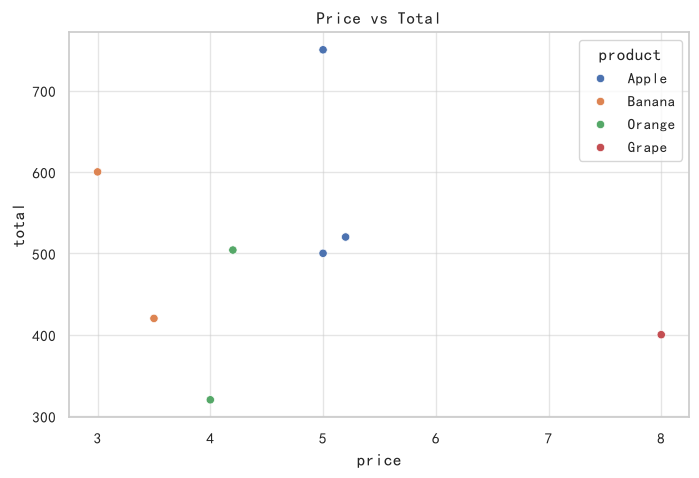

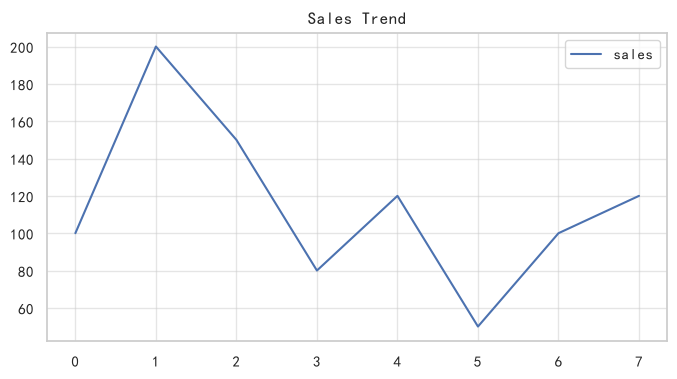

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='price',y='total',hue='product')
plt.title("Price vs Total")
plt.show()

df.plot(kind='line',y='sales',grid=True,figsize=(8,4),title="Sales Trend")
plt.show()

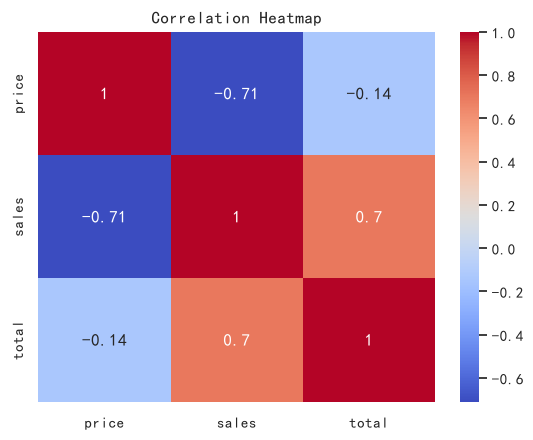

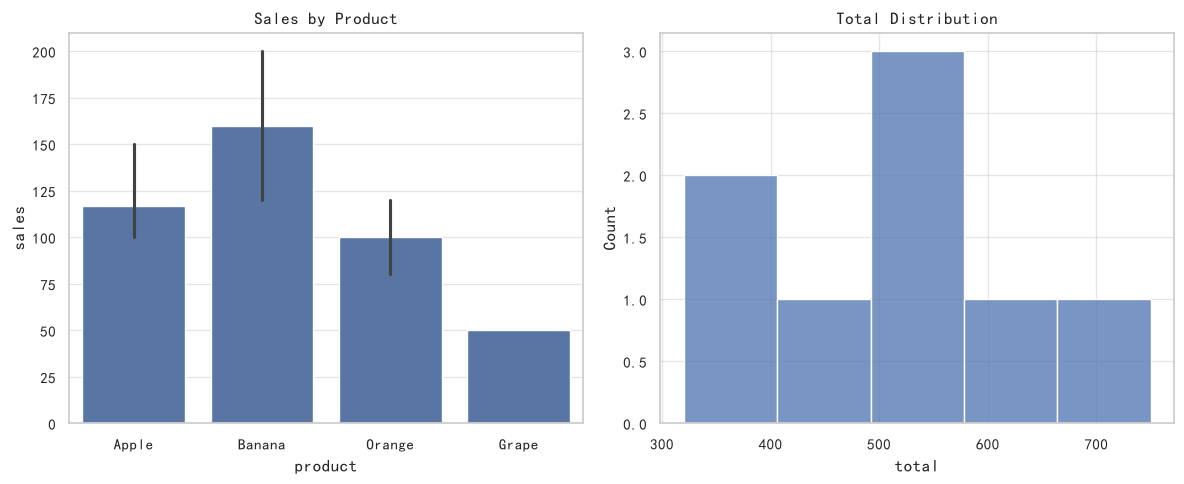

In [17]:
num_cols=df[['price','sales','total']]
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=df,x='product',y='sales',ax=axes[0])
axes[0].set_title("Sales by Product")
sns.histplot(data=df,x='total',bins=5,ax=axes[1])
axes[1].set_title("Total Distribution")
plt.tight_layout()

plt.savefig("exercise_chart.png", dpi=300, bbox_inches='tight')
plt.show()

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [19]:
df = pd.DataFrame({
    'emp_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'name': ['Alice', 'Bob', 'Charlie', 'David', 'Eve', 'Frank', 'Grace', 'Helen', 'Ivy', 'Jack'],
    'dept': ['HR', 'IT', 'IT', 'HR', 'Finance', 'IT', 'Finance', 'HR', 'IT', 'Finance'],
    'salary': [5000, 12000, 15000, 6000, None, 11000, 9000, 5500, 13000, 8000],
    'performance': [3.5, 4.0, 4.8, 3.8, 4.2, 4.5, 3.9, 3.2, 4.7, 4.0],
    'join_year': [2018, 2019, 2017, 2020, 2019, 2016, 2018, 2021, 2017, 2020]
})

In [20]:
df['salary']=df['salary'].fillna(df['salary'].mean())
df['bonus']=df['salary']*df['performance']*0.1
print(df.head())

   emp_id     name     dept        salary  performance  join_year        bonus
0       1    Alice       HR   5000.000000          3.5       2018  1750.000000
1       2      Bob       IT  12000.000000          4.0       2019  4800.000000
2       3  Charlie       IT  15000.000000          4.8       2017  7200.000000
3       4    David       HR   6000.000000          3.8       2020  2280.000000
4       5      Eve  Finance   9388.888889          4.2       2019  3943.333333


In [21]:
it_high_perf=df[(df['dept']=='IT')&(df['performance']>4.0)]
print("---IT部门高绩效员工---")
print(it_high_perf)

dept_stats=df.groupby('dept')[['salary','bonus']].agg(['mean','max']).reset_index()
dept_stats.sort_values(by=('salary','mean'),ascending=False,inplace=True)
print("\n---部门统计---")
print(dept_stats)

---IT部门高绩效员工---
   emp_id     name dept   salary  performance  join_year   bonus
2       3  Charlie   IT  15000.0          4.8       2017  7200.0
5       6    Frank   IT  11000.0          4.5       2016  4950.0
8       9      Ivy   IT  13000.0          4.7       2017  6110.0

---部门统计---
      dept        salary                      bonus             
                    mean           max         mean          max
2       IT  12750.000000  15000.000000  5765.000000  7200.000000
0  Finance   8796.296296   9388.888889  3551.111111  3943.333333
1       HR   5500.000000   6000.000000  1930.000000  2280.000000


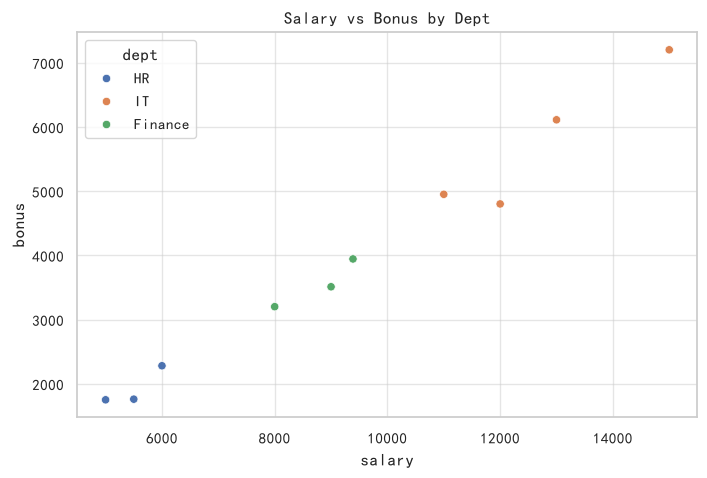

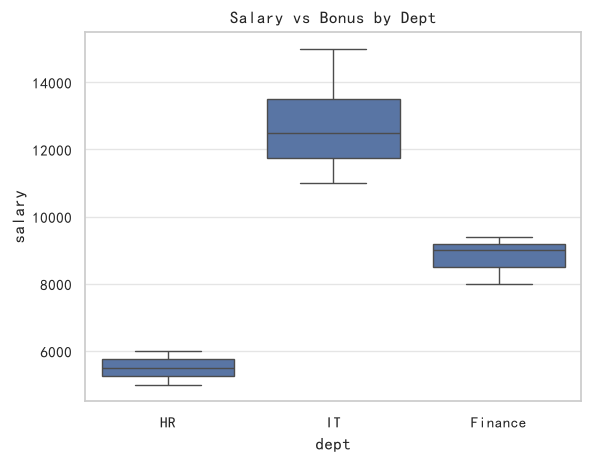

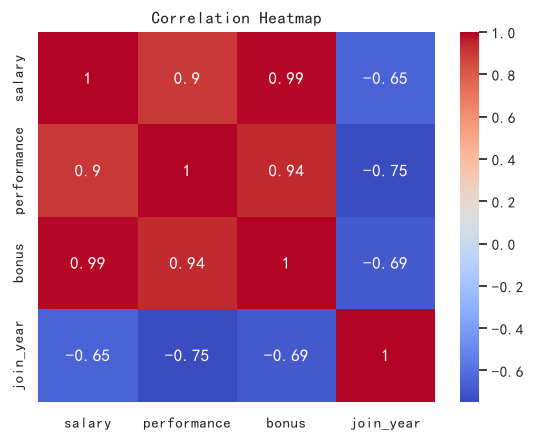

In [23]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='salary',y='bonus',hue='dept')
plt.title("Salary vs Bonus by Dept")
plt.show()

sns.boxplot(data=df,x='dept',y='salary')
plt.title("Salary vs Bonus by Dept")
plt.show()

num_cols=df[['salary','performance','bonus','join_year']]
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

In [25]:
df = pd.DataFrame({
    'student_id': [1, 2, 3, 4, 5, 6, 7, 8, 8], # 注意 8 号重复了
    'course': ['Python', 'Math', 'Python', 'Math', 'Python', 'Art', 'Math', 'Python', 'Python'],
    'hours': [10, 15, 8, 20, 12, 5, 18, None, None], # 有空值
    'score': [85, 90, 78, 95, 88, 70, None, 82, 82],
    'completed': ['Yes', 'Yes', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes']
})

In [26]:
df.drop_duplicates(subset=['student_id'], inplace=True)
df['hour']=df['hours'].fillna(df['hours'].mean())
df['score']=df['score'].fillna(df['score'].mean())
df['efficiency']=df['score']/df['hour']
print(df.head())

   student_id  course  hours  score completed  hour  efficiency
0           1  Python   10.0   85.0       Yes  10.0    8.500000
1           2    Math   15.0   90.0       Yes  15.0    6.000000
2           3  Python    8.0   78.0        No   8.0    9.750000
3           4    Math   20.0   95.0       Yes  20.0    4.750000
4           5  Python   12.0   88.0       Yes  12.0    7.333333


In [27]:
print("---Loc Result---")
print(df.loc[0:2,['student_id','course','score']])

print("\n---ILoc Result---")
print(df.iloc[0:3,0:3])

print("\n--- Query Result---")
print(df.query('completed=="Yes" and score>80'))

df.sort_values(by='score',ascending=False,inplace=True)
df.reset_index(drop=True,inplace=True)

---Loc Result---
   student_id  course  score
0           1  Python   85.0
1           2    Math   90.0
2           3  Python   78.0

---ILoc Result---
   student_id  course  hours
0           1  Python   10.0
1           2    Math   15.0
2           3  Python    8.0

--- Query Result---
   student_id  course  hours  score completed       hour  efficiency
0           1  Python   10.0   85.0       Yes  10.000000    8.500000
1           2    Math   15.0   90.0       Yes  15.000000    6.000000
3           4    Math   20.0   95.0       Yes  20.000000    4.750000
4           5  Python   12.0   88.0       Yes  12.000000    7.333333
6           7    Math   18.0   84.0       Yes  18.000000    4.666667
7           8  Python    NaN   82.0       Yes  12.571429    6.522727


In [29]:
course_stats=df.groupby('course').agg({
    'score':'mean',
    'hour':'max',
    'student_id':'count',
}).reset_index()
print("---课程统计---")
print(course_stats)

print("\n---课程报名人数---")
print(df['course'].value_counts())

---课程统计---
   course      score       hour  student_id
0     Art  70.000000   5.000000           1
1    Math  89.666667  20.000000           3
2  Python  83.250000  12.571429           4

---课程报名人数---
course
Python    4
Math      3
Art       1
Name: count, dtype: int64


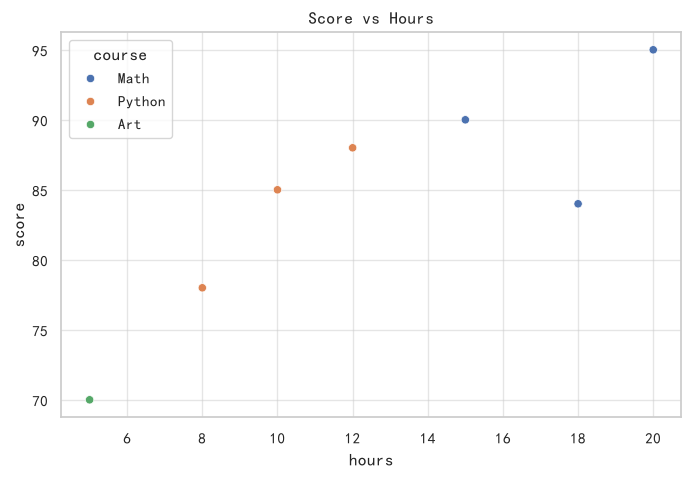

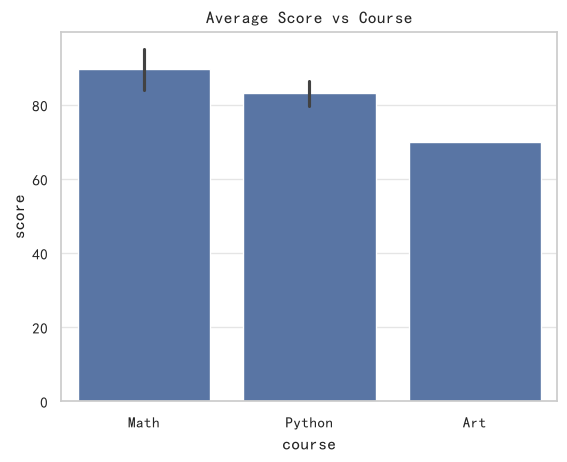

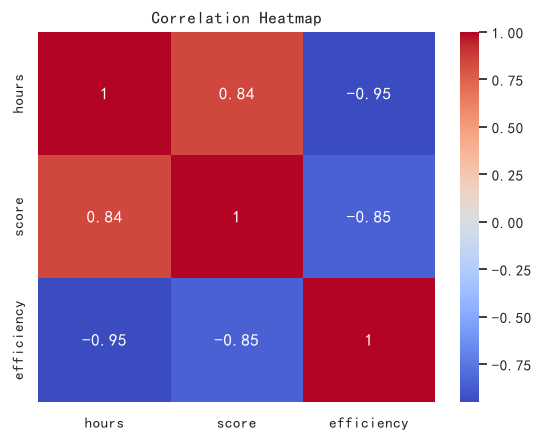

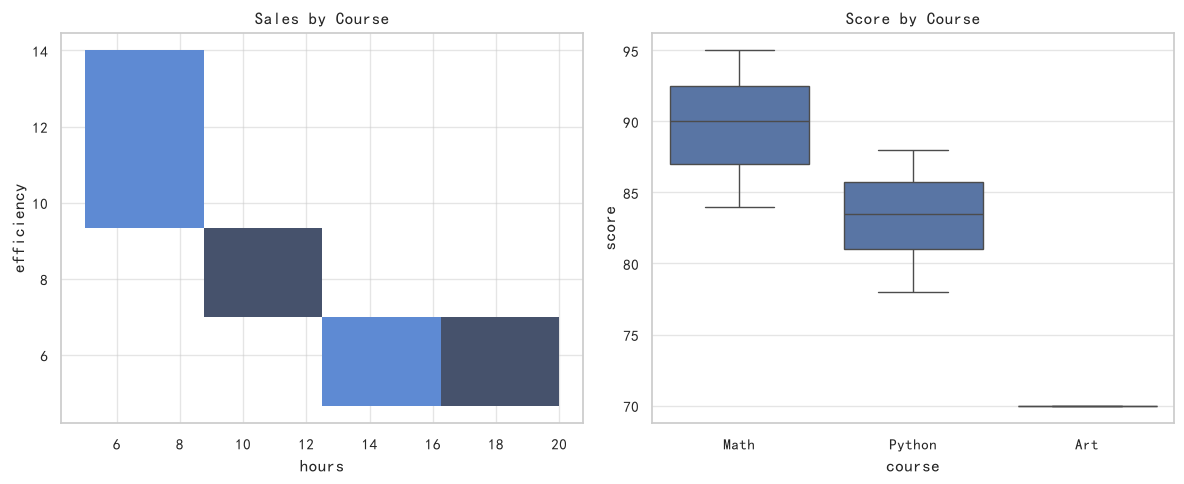


全部通关！快去看看 exercise_chart.png 长什么样吧！


In [31]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='hours',y='score',hue='course')
plt.title("Score vs Hours")
plt.show()

sns.barplot(data=df,x='course',y='score')
plt.title("Average Score vs Course")
plt.show()

num_cols=df[['hours','score','efficiency']]
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x='hours',y='efficiency',ax=axes[0])
axes[0].set_title("Sales by Course")
sns.boxplot(data=df,x='course',y='score',ax=axes[1])
axes[1].set_title("Score by Course")
plt.tight_layout()
plt.savefig("exercise_chart.png", dpi=300, bbox_inches='tight')
plt.show()
print("\n全部通关！快去看看 exercise_chart.png 长什么样吧！")

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

# 模拟一份用户消费数据（直接复制）
df = pd.DataFrame({
    'user_id': [1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
    'city': ['Beijing', 'Shanghai', 'Beijing', 'Shenzhen', 'Shanghai', 'Beijing', 'Beijing', 'Shenzhen', 'Shanghai', 'Shanghai'],
    'age': [22, 25, 30, 35, 28, 40, 22, 30, 25, None],
    'income': [50000, 80000, 120000, 150000, 60000, 200000, 55000, 110000, 90000, 100000],
    'spend': [500, 1200, 2000, 800, None, 2500, 600, 1800, None, 1500],
    'sessions': [10, 20, 15, 8, 12, 30, 10, 18, 14, 20]
})
# 预览一下
print(df.head())

   user_id      city   age  income   spend  sessions
0        1   Beijing  22.0   50000   500.0        10
1        2  Shanghai  25.0   80000  1200.0        20
2        3   Beijing  30.0  120000  2000.0        15
3        4  Shenzhen  35.0  150000   800.0         8
4        5  Shanghai  28.0   60000     NaN        12


In [3]:
df['age']=df['age'].fillna(df['age'].mean())
df['spend']=df['spend'].fillna(df['spend'].mean())
df['spend_per_session']=df['spend']/df['sessions']
df.sort_values(by='spend',ascending=False,inplace=True)
df.reset_index(drop=True,inplace=True)

In [4]:
filtered_users=df[(df['city']=='Beijing')&(df['income']>6000)]
print("---筛选结果---")
print(filtered_users)

filtered_query=df.query('city=="Beijing" and income>6000')
print("\n---Query 结果---")
print(filtered_query)

print("\n---Loc 切片---")
print(df.loc[0:2,['user_id','spend_per_session']])

city_stats=df.groupby('city').agg({
    'income':'mean',
    'spend':'mean',
    'user_id':'count',
}).reset_index()
print("\n--- 城市统计---")
print(city_stats)

---筛选结果---
   user_id     city   age  income   spend  sessions  spend_per_session
0        6  Beijing  40.0  200000  2500.0        30          83.333333
1        3  Beijing  30.0  120000  2000.0        15         133.333333
8        7  Beijing  22.0   55000   600.0        10          60.000000
9        1  Beijing  22.0   50000   500.0        10          50.000000

---Query 结果---
   user_id     city   age  income   spend  sessions  spend_per_session
0        6  Beijing  40.0  200000  2500.0        30          83.333333
1        3  Beijing  30.0  120000  2000.0        15         133.333333
8        7  Beijing  22.0   55000   600.0        10          60.000000
9        1  Beijing  22.0   50000   500.0        10          50.000000

---Loc 切片---
   user_id  spend_per_session
0        6          83.333333
1        3         133.333333
2        8         100.000000

--- 城市统计---
       city    income    spend  user_id
0   Beijing  106250.0  1400.00        4
1  Shanghai   82500.0  1356.25      

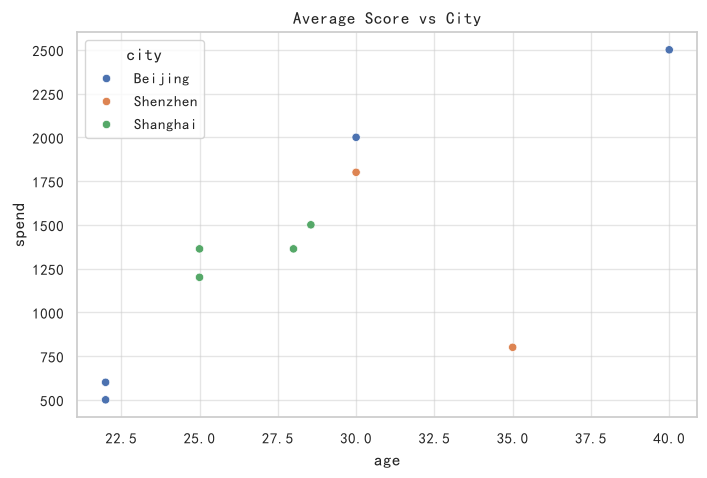

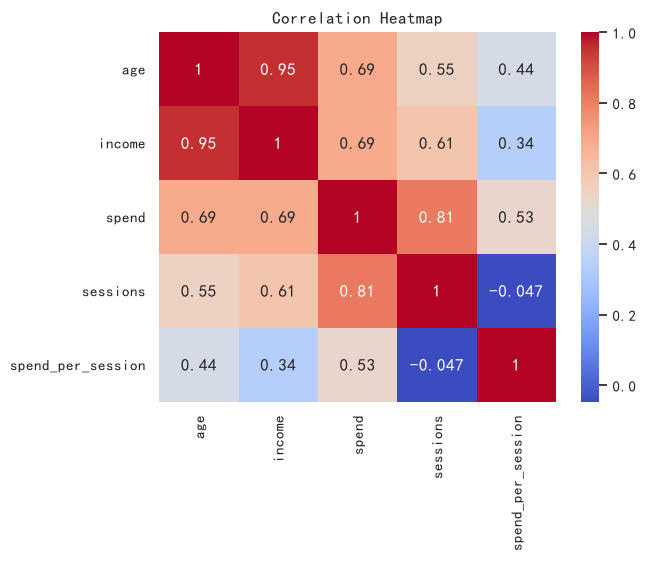

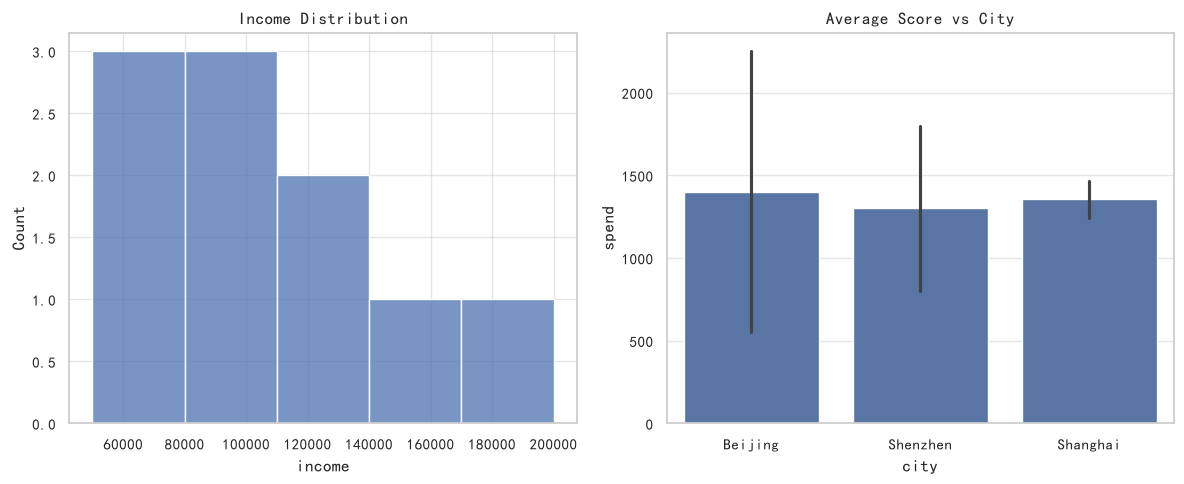

In [5]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='age',y='spend',hue='city')
plt.title("Average Score vs City")
plt.show()

num_cols=df[['age','income','spend','sessions','spend_per_session']]
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.histplot(data=df,x='income',bins=5,ax=axes[0])
axes[0].set_title("Income Distribution")
sns.barplot(data=df,x='city',y='spend',ax=axes[1])
axes[1].set_title("Average Score vs City")
plt.tight_layout()
plt.show()

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

df = pd.DataFrame({
    'book_id': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'title': ['Python入门', '数学之美', 'Python进阶', '历史那些事', '数学分析', 'Python编程', '历史故事', '数学之美', 'Python入门', '历史那些事'],
    'category': ['Tech', 'Math', 'Tech', 'History', 'Math', 'Tech', 'History', 'Math', 'Tech', 'History'],
    'borrow_count': [15, 8, 20, 5, 12, 25, 4, 10, 18, 6],
    'overdue_days': [3, 0, 7, 2, None, 5, 10, 1, None, 4],
    'member_age': [20, 25, 22, 30, 28, 35, 40, 24, 21, 33],
    'member_level': ['Gold', 'Silver', 'Gold', 'Bronze', 'Silver', 'Gold', 'Bronze', 'Silver', 'Gold', 'Bronze']
})
print("原始数据：")
print(df.head())

原始数据：
   book_id     title category  borrow_count  overdue_days  member_age  \
0      101  Python入门     Tech            15           3.0          20   
1      102      数学之美     Math             8           0.0          25   
2      103  Python进阶     Tech            20           7.0          22   
3      104     历史那些事  History             5           2.0          30   
4      105      数学分析     Math            12           NaN          28   

  member_level  
0         Gold  
1       Silver  
2         Gold  
3       Bronze  
4       Silver  


In [7]:
df.drop_duplicates(subset=['book_id'], inplace=True)
df['overdue_days']=df['overdue_days'].fillna(df['overdue_days'].mean())
df['fine']=df['overdue_days']*0.5
df['popularity']=df['borrow_count']/df['member_age']
print("\n清洗并计算后的数据：")
print(df.head())


清洗并计算后的数据：
   book_id     title category  borrow_count  overdue_days  member_age  \
0      101  Python入门     Tech            15           3.0          20   
1      102      数学之美     Math             8           0.0          25   
2      103  Python进阶     Tech            20           7.0          22   
3      104     历史那些事  History             5           2.0          30   
4      105      数学分析     Math            12           4.0          28   

  member_level  fine  popularity  
0         Gold   1.5    0.750000  
1       Silver   0.0    0.320000  
2         Gold   3.5    0.909091  
3       Bronze   1.0    0.166667  
4       Silver   2.0    0.428571  


In [8]:
borrow_array=np.array(df['borrow_count'])
print(f"借阅次数均值：{borrow_array.mean():.2f}")
print(f"借阅次数均值：{borrow_array.var():.2f}")

weights=np.array([0.6,0.4])
scores=np.dot(df[['borrow_count','overdue_days']].values,weights)
df['score']=scores
print("\n新增的权重得分列：")
print(df[['book_id','borrow_count','overdue_days','score']].head())

def f(x):
    return x**2+3*x
x=2
h=0.0001
derivative_approx=(f(x+h)-f(x-h))/h
print(f"\n函数在x{x}的近似导数：{derivative_approx:.2f}(理论值：2*{x}+3=7))")

借阅次数均值：12.30
借阅次数均值：44.61

新增的权重得分列：
   book_id  borrow_count  overdue_days  score
0      101            15           3.0   10.2
1      102             8           0.0    4.8
2      103            20           7.0   14.8
3      104             5           2.0    3.8
4      105            12           4.0    8.8

函数在x2的近似导数：14.00(理论值：2*2+3=7))


In [10]:
print("---Loc切片---")
print(df.loc[0:2,['title','category','fine']])

print("\n---ILoc切片---")
print(df.iloc[0:3,0:3])

print("\n---Query筛选---")
print(df.query('category=="Tech" and borrow_count>15'))

category_stats=df.groupby('category').agg({
    'borrow_count':'sum',
    'overdue_days':'mean',
    'book_id':'count',
}).reset_index()
print("\n---分类统计---")
print(category_stats)

df.sort_values(by='overdue_days',ascending=False,inplace=True)
df.reset_index(drop=True,inplace=True)

---Loc切片---
      title category  fine
0  Python入门     Tech   1.5
1      数学之美     Math   0.0
2  Python进阶     Tech   3.5

---ILoc切片---
   book_id     title category
0      101  Python入门     Tech
1      102      数学之美     Math
2      103  Python进阶     Tech

---Query筛选---
   book_id     title category  borrow_count  overdue_days  member_age  \
2      103  Python进阶     Tech            20           7.0          22   
5      106  Python编程     Tech            25           5.0          35   
8      109  Python入门     Tech            18           4.0          21   

  member_level  fine  popularity  score  
2         Gold   3.5    0.909091   14.8  
5         Gold   2.5    0.714286   17.0  
8         Gold   2.0    0.857143   12.4  

---分类统计---
  category  borrow_count  overdue_days  book_id
0  History            15      5.333333        3
1     Math            30      1.666667        3
2     Tech            78      4.750000        4


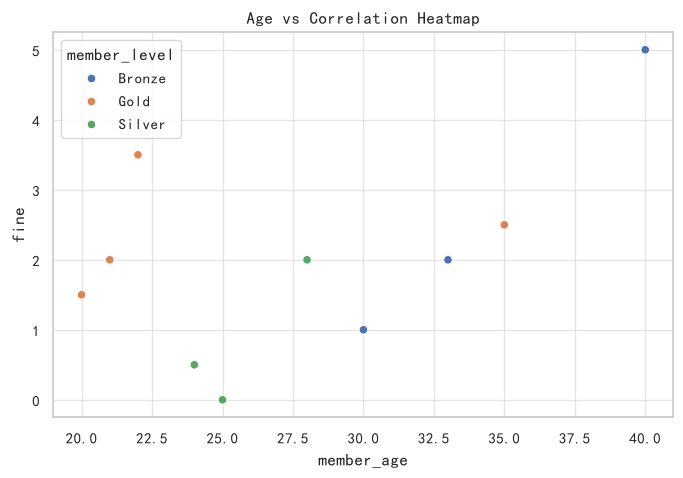

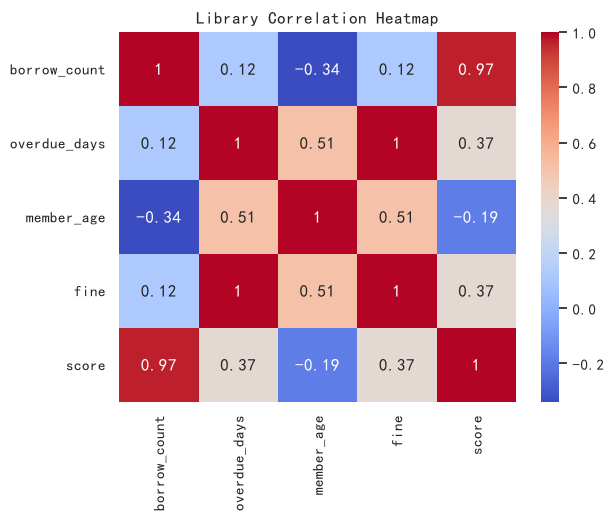

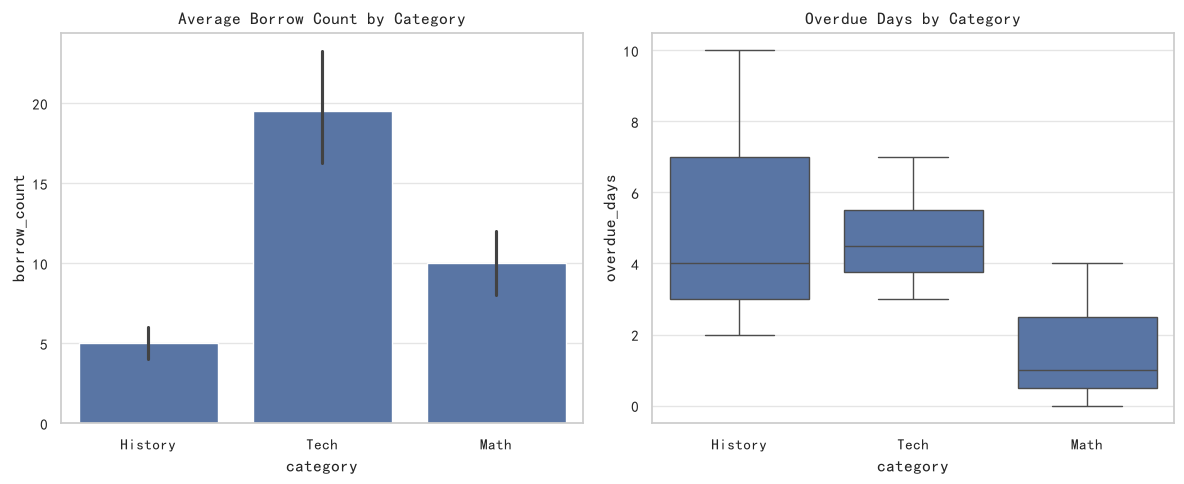

In [13]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df,x='member_age',y='fine',hue='member_level')
plt.title("Age vs Correlation Heatmap")
plt.show()

num_cols=df[['borrow_count','overdue_days','member_age','fine','score']]
sns.heatmap(num_cols.corr(),annot=True,cmap='coolwarm')
plt.title("Library Correlation Heatmap")
plt.show()

fig,axes=plt.subplots(1,2,figsize=(12,5))
sns.barplot(data=df,x='category',y='borrow_count',ax=axes[0])
axes[0].set_title("Average Borrow Count by Category")

sns.boxplot(data=df,x='category',y='overdue_days',ax=axes[1])
axes[1].set_title("Overdue Days by Category")

plt.tight_layout()
plt.savefig("library_analysis.png",dpi=300,bbox_inches='tight')
plt.show()